# Разведочный анализ данных: California Housing

EDA для датасета California Housing (`housing.csv`): анализ признаков, распределения, пропуски, целевая переменная `median_house_value` и связи с остальными признаками.


In [ ]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use("seaborn-v0_8")
sns.set_theme()

DATA_PATH = os.path.join("..", "datasets", "housing", "housing.csv")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

df = pd.read_csv(DATA_PATH)

print("Форма датасета:", df.shape)
display(df.head())

print("\nТипы столбцов:")
print(df.dtypes)

print("\nИнформация о данных:")
df.info()

print("\nОписательная статистика числовых признаков:")
display(df.describe(include=[np.number]).T)

print("\nОписательная статистика категориальных признаков:")
display(df.describe(include=["object", "category"]).T)

print("\nЧисло дубликатов:", df.duplicated().sum())

missing = df.isna().sum().sort_values(ascending=False)
print("\nПропуски по столбцам:")
display(missing[missing > 0])

target_col = "median_house_value"
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols]
sample_df = df.sample(n=min(len(df), 5000), random_state=42)


Форма датасета: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



Типы столбцов:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64


,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000



Описательная статистика категориальных признаков:


,count,unique,top,freq
ocean_proximity,20640,5,<1H OCEAN,9136



Число дубликатов: 0

Пропуски по столбцам:


total_bedrooms    207
dtype: int64

## Целевая переменная
Распределение целевой переменной `median_house_value`.

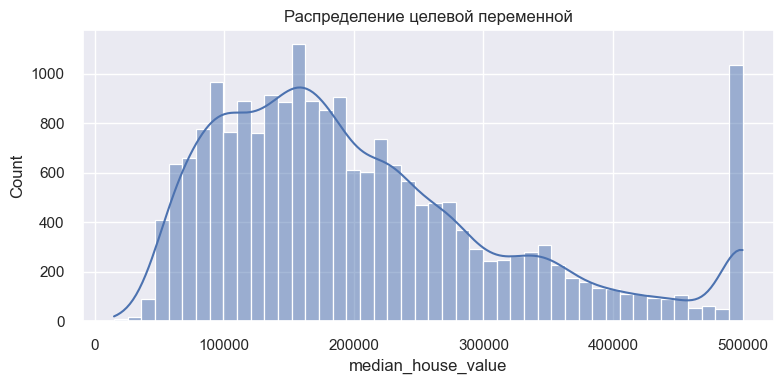

In [ ]:
if target_col in df.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[target_col], kde=True)
    plt.title("Распределение целевой переменной")
    plt.tight_layout()
    plt.show()

## Распределения числовых признаков
Гистограммы числовых признаков (на сэмпле).

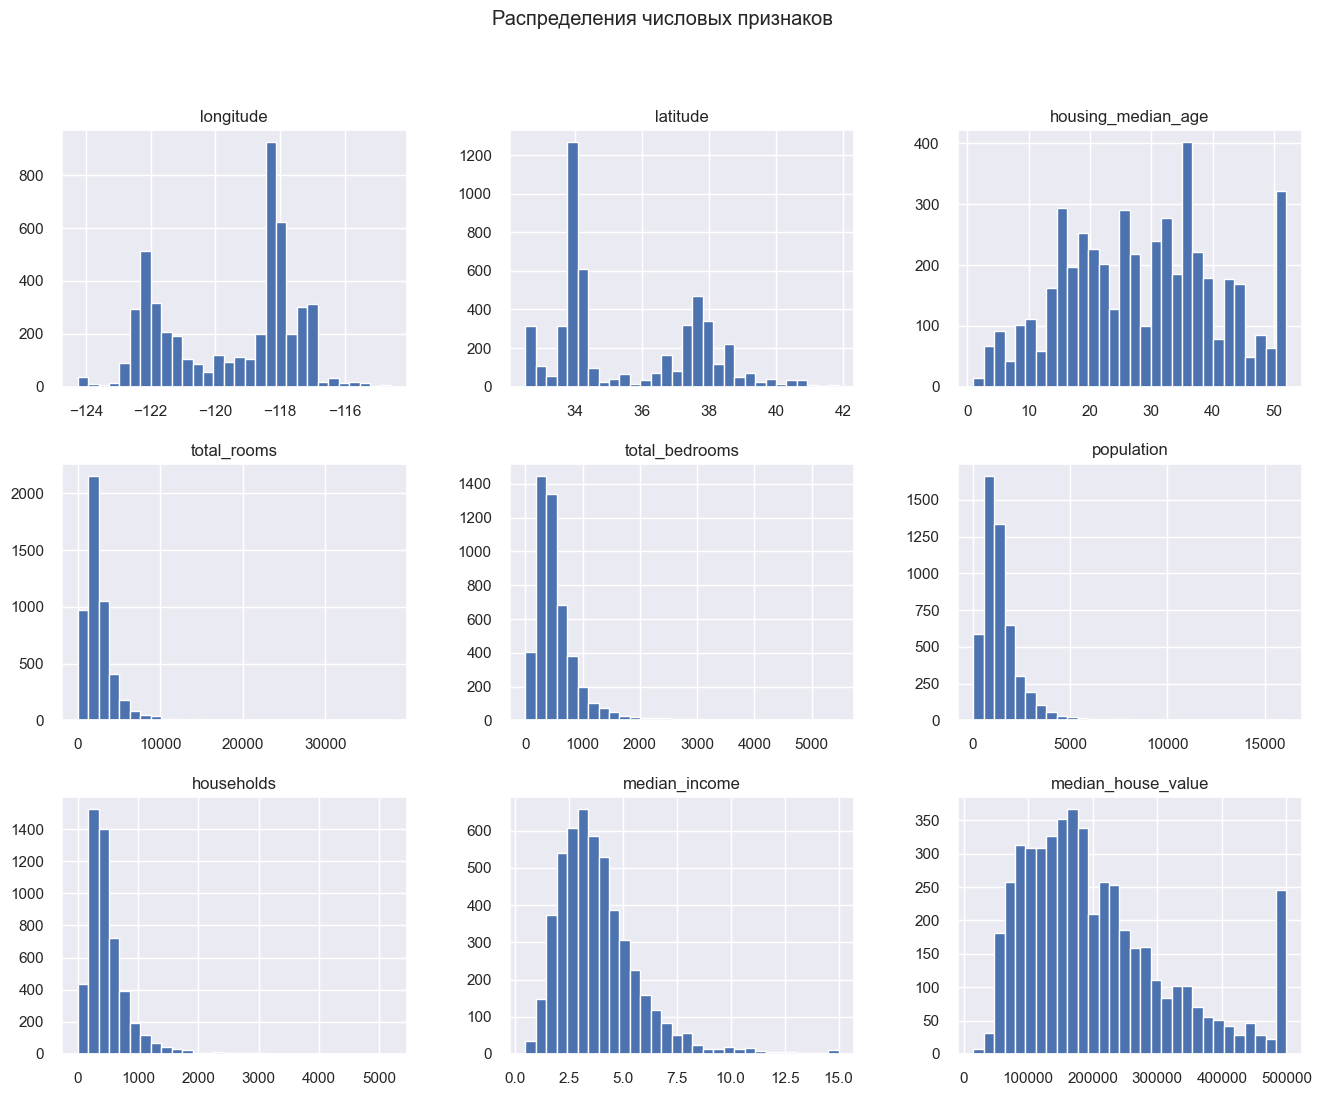

In [ ]:
if numeric_cols:
    sample_df[numeric_cols].hist(bins=30, figsize=(16, 12))
    plt.suptitle("Распределения числовых признаков")
    plt.show()

## Категориальные признаки
Распределение категориального признака `ocean_proximity`.

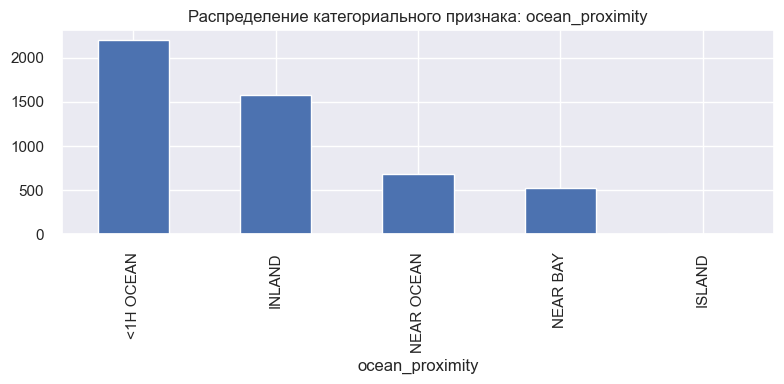

In [ ]:
if categorical_cols:
    for col in categorical_cols:
        plt.figure(figsize=(8, 4))
        sample_df[col].value_counts().plot(kind="bar")
        plt.title(f"Распределение категориального признака: {col}")
        plt.tight_layout()
        plt.show()

## Корреляционная матрица
Корреляции Пирсона между числовыми признаками (числа в ячейках — коэффициенты корреляции).

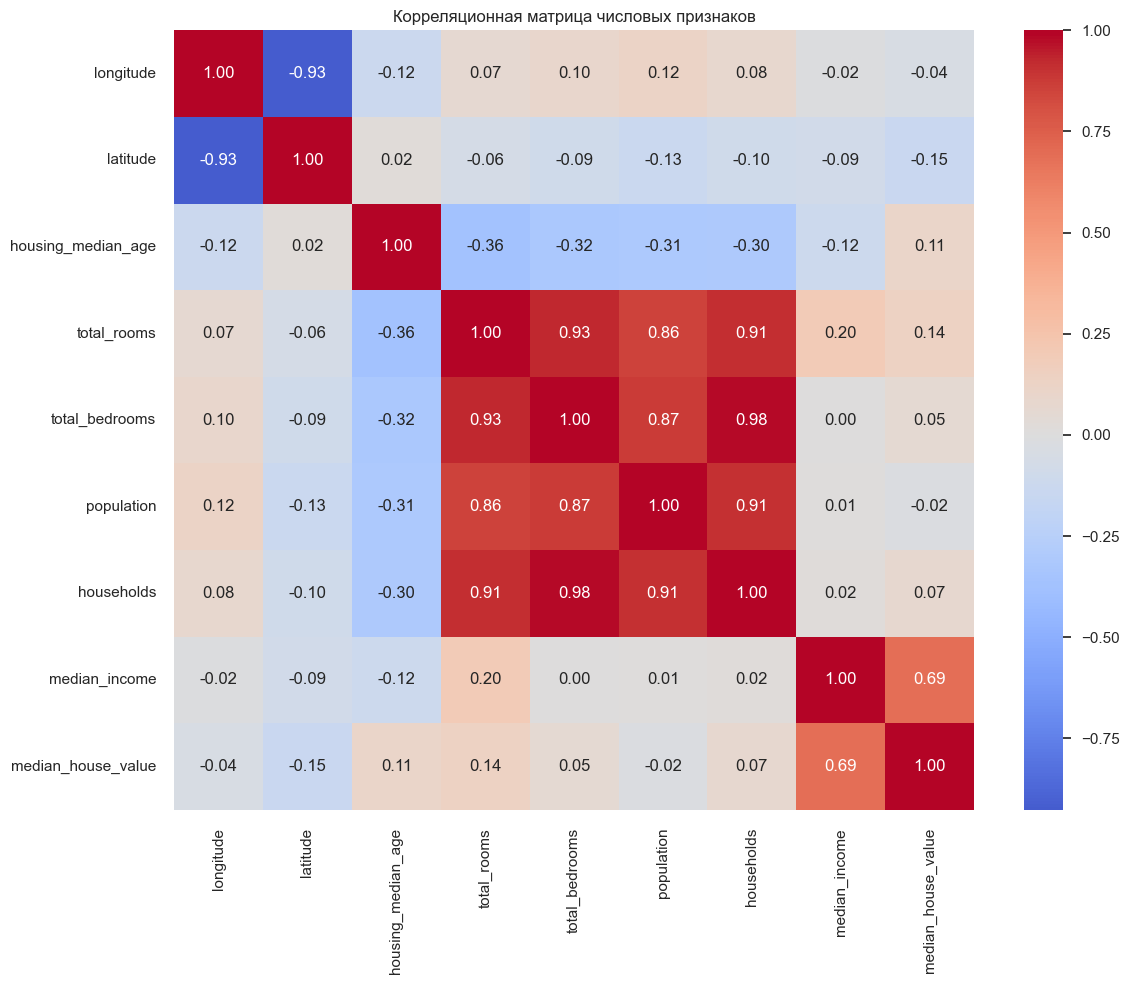

In [ ]:
if numeric_cols:
    plt.figure(figsize=(12, 10))
    corr = sample_df[numeric_cols].corr()
    sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
    plt.title("Корреляционная матрица числовых признаков")
    plt.tight_layout()
    plt.show()

## Связь признаков с целевой переменной
Диаграммы рассеяния: каждый признак vs `median_house_value`.

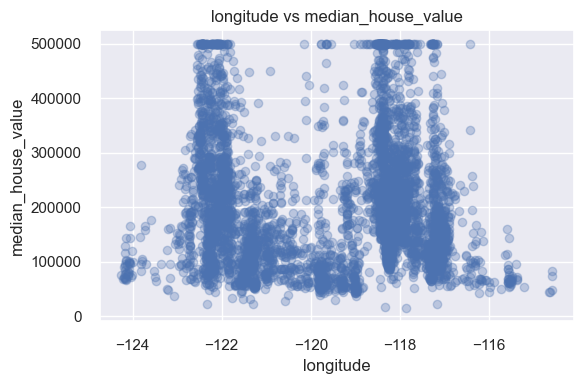

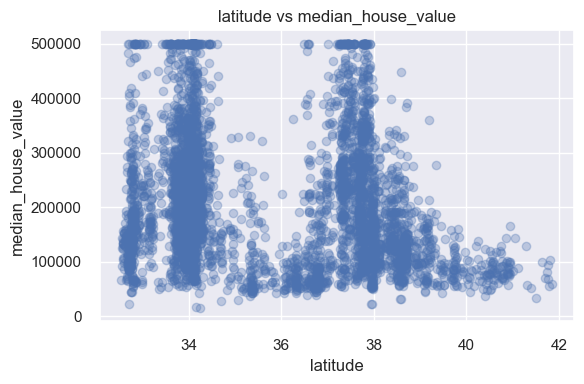

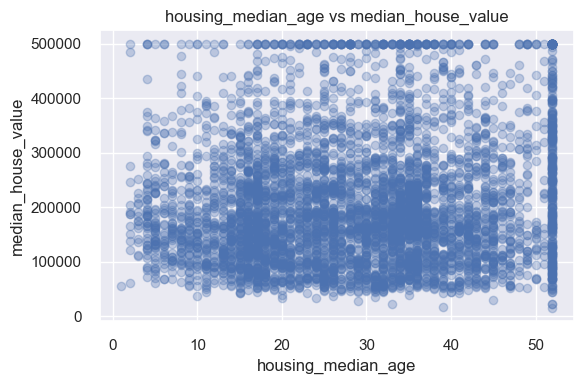

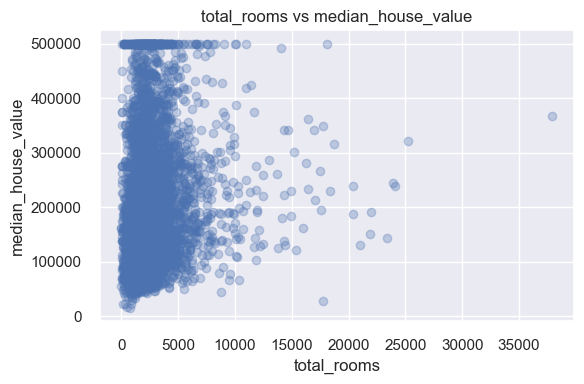

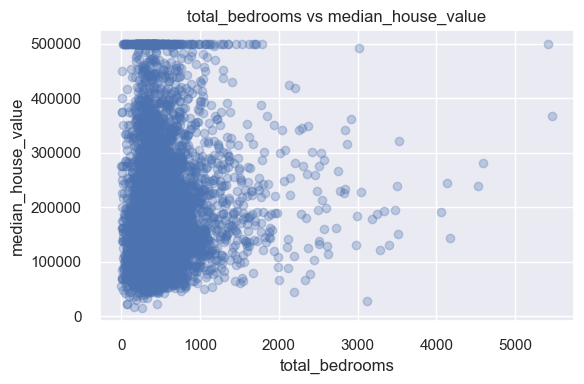

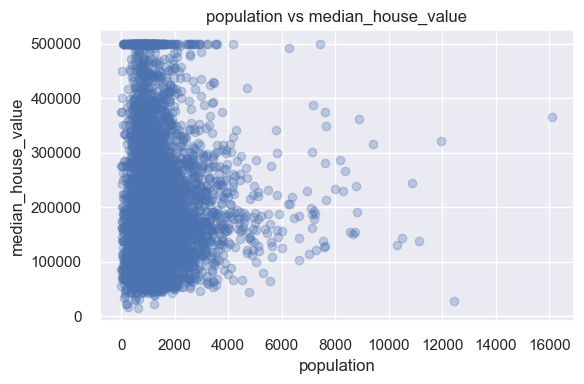

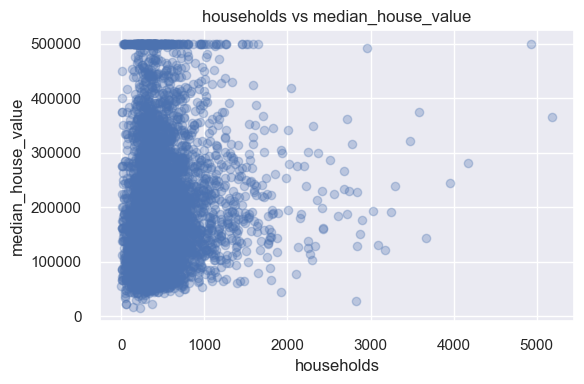

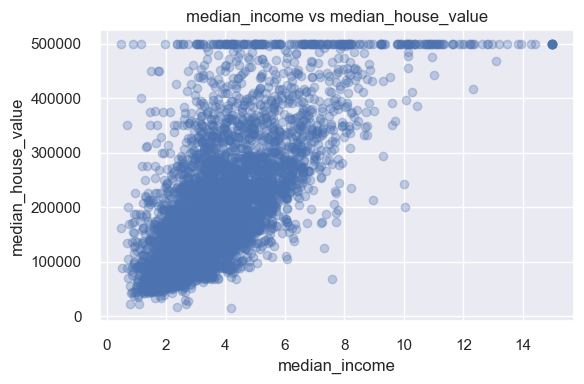

In [ ]:
if target_col in df.columns:
    for col in numeric_cols:
        if col == target_col:
            continue
        plt.figure(figsize=(6, 4))
        plt.scatter(sample_df[col], sample_df[target_col], alpha=0.3)
        plt.xlabel(col)
        plt.ylabel(target_col)
        plt.title(f"{col} vs {target_col}")
        plt.tight_layout()
        plt.show()